# 00 — Quick start: ใช้ digital twin ผ่าน `DigitalTwin` วัตถุเดียว

Notebook 01–04 เป็น *pipeline สร้าง* twin (point cloud → โมเดลห้อง → โซน/อุปกรณ์/ท่อ → ข้อมูล IoT) — เมื่อไฟล์ใน `data/model`, `data/sensors`, `data/processed` มีแล้ว ใช้งานทั้งหมดได้จากหน้านี้

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


In [2]:
from pfal_twin.twin import DigitalTwin
twin = DigitalTwin.load()
print(twin.summary())

room 7.12 x 3.01 x 2.58 m | rack 5.43 x 1.04 m, 5 tiers | zones 14
equipment 29 items (28 verified) | sensors 10 | pipe edges 42
IoT 2025-12-26 -> 2026-09-14 18:30, 37,772 x 10-min bins, room T/RH in 3,536 bins


## สภาพห้อง ณ เวลาหนึ่ง

In [3]:
st = twin.state("2026-09-11 12:10")
{k: v for k, v in st.as_dict().items() if k in ("time", "room_T", "room_RH", "co2", "ec", "ph", "pump_on")}

{'time': Timestamp('2026-09-11 12:10:00+0700', tz='Asia/Bangkok'),
 'room_T': 30.733333333333334,
 'room_RH': 63.96666666666666,
 'co2': 539.0,
 'ec': {'growing (gc1)': nan, 'nursery-2 (gc2)': nan},
 'ph': {'growing (gc1)': nan, 'nursery-2 (gc2)': nan},
 'pump_on': {'gc1': False, 'gc2': False}}

In [4]:
twin.show("2026-09-11 12:10", "T")          # 3-D (ปุ่ม Full screen / ไฟล์ html)

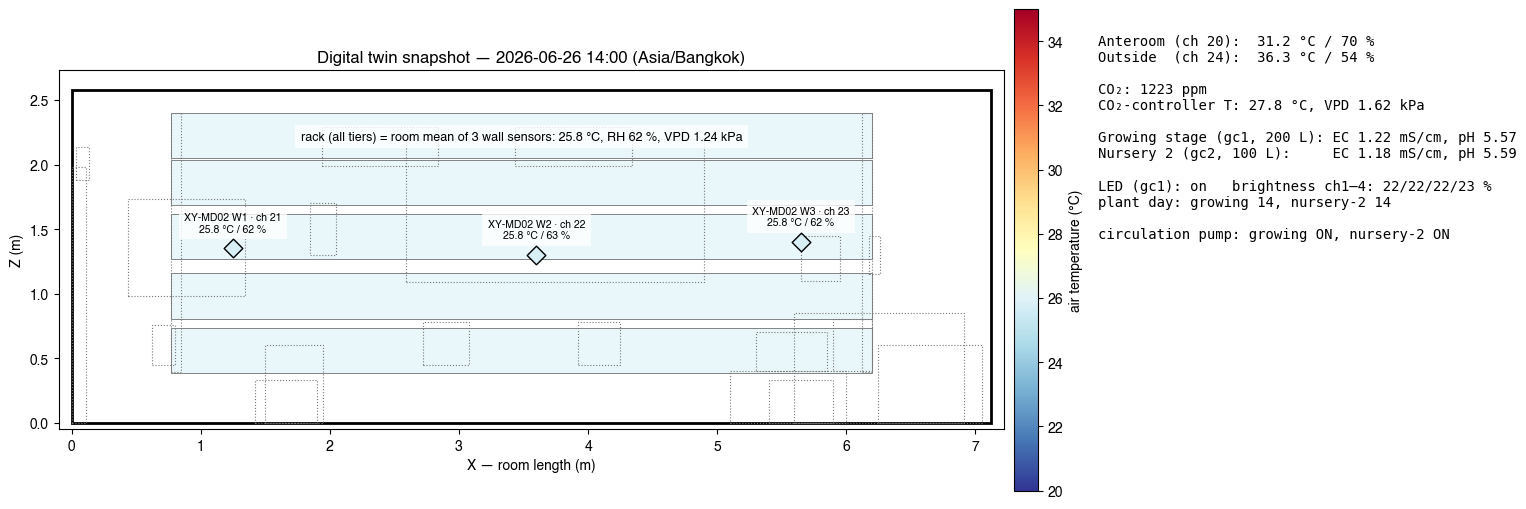

In [5]:
twin.snapshot("2026-06-26 14:00");         # 2-D สำหรับบทความ

## ตาราง

In [6]:
display(twin.kpi()); twin.events(save=False).head()

,location,zone,T mean °C,T max °C,hours T > 30 °C,RH mean %,hours RH > 85 %,VPD mean kPa,hours VPD out of range,data hours
channel,,,,,,,,,,
xy_md_21,"Grower room 1 (wall, X 1.25 m)",room,24.17,30.6,0.33,67.19,79.17,0.99,95.00,575.17
xy_md_22,"Grower room 2 (wall, X 3.6 m)",room,24.26,30.6,0.33,67.67,79.17,0.98,95.17,573.83
xy_md_23,"Grower room 3 (wall, X 5.65 m)",room,24.41,31.0,0.33,66.50,74.67,1.02,97.83,572.00
xy_md_20,Inside = anteroom (above the door),anteroom,27.33,32.7,53.83,65.66,3.83,1.27,122.33,573.50
xy_md_24,Outside (on the CO2 box),outside,30.69,38.0,297.50,71.47,98.83,1.37,280.17,574.17


,event,start,end,hours,peak
0,nursery-2 100 L pH outside 5.5–6.5,2026-09-14 18:10:00+07:00,2026-09-14 18:30:00+07:00,0.5,7.22
1,nursery-2 100 L pH outside 5.5–6.5,2026-09-14 16:50:00+07:00,2026-09-14 17:10:00+07:00,0.5,7.22
2,nursery-2 100 L pH outside 5.5–6.5,2026-09-14 15:40:00+07:00,2026-09-14 16:00:00+07:00,0.5,7.23
3,nursery-2 100 L pH outside 5.5–6.5,2026-09-14 14:10:00+07:00,2026-09-14 15:20:00+07:00,1.3,7.21
4,nursery-2 100 L pH outside 5.5–6.5,2026-09-14 12:10:00+07:00,2026-09-14 13:50:00+07:00,1.8,7.22


## ผัง / ระบบน้ำ / การไหล

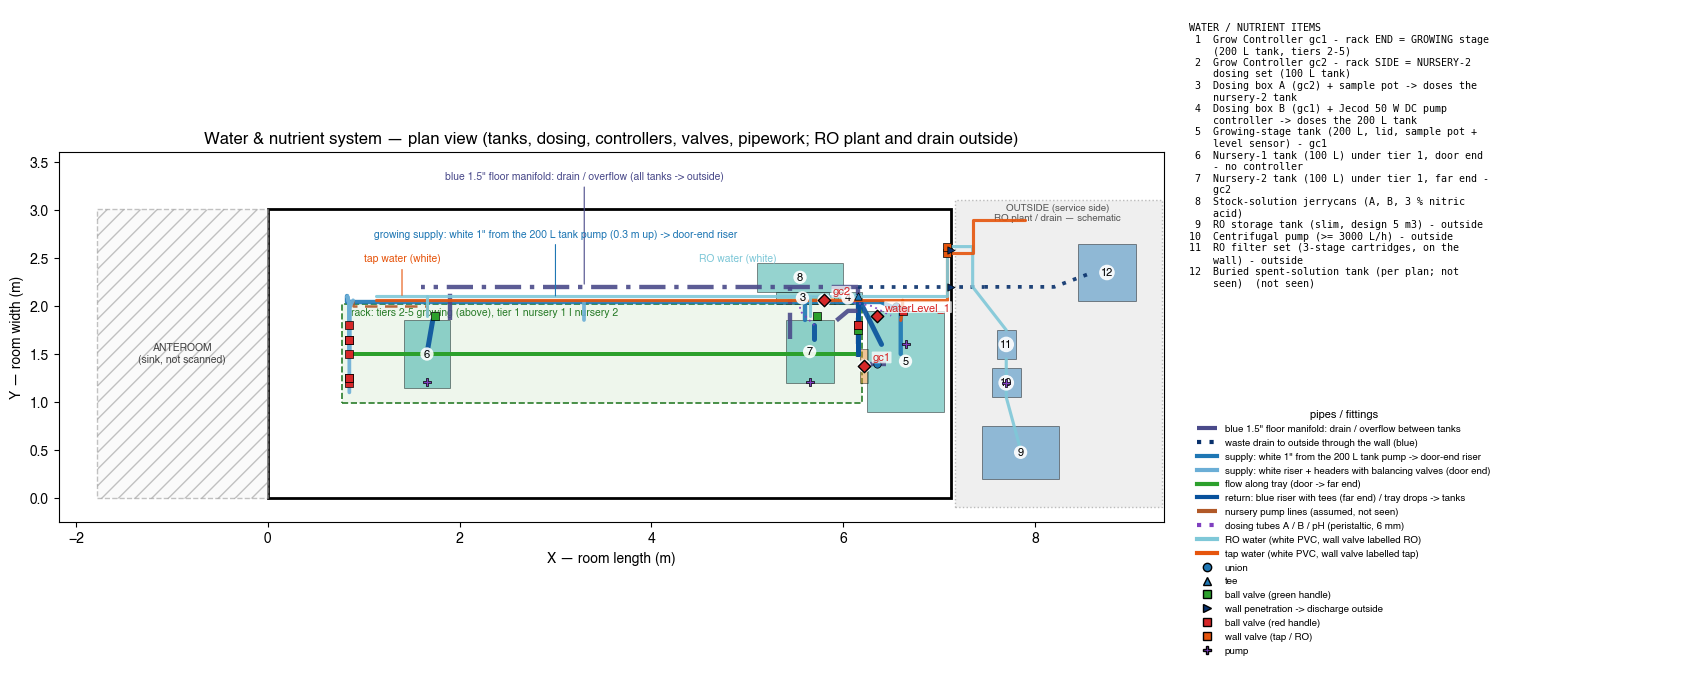

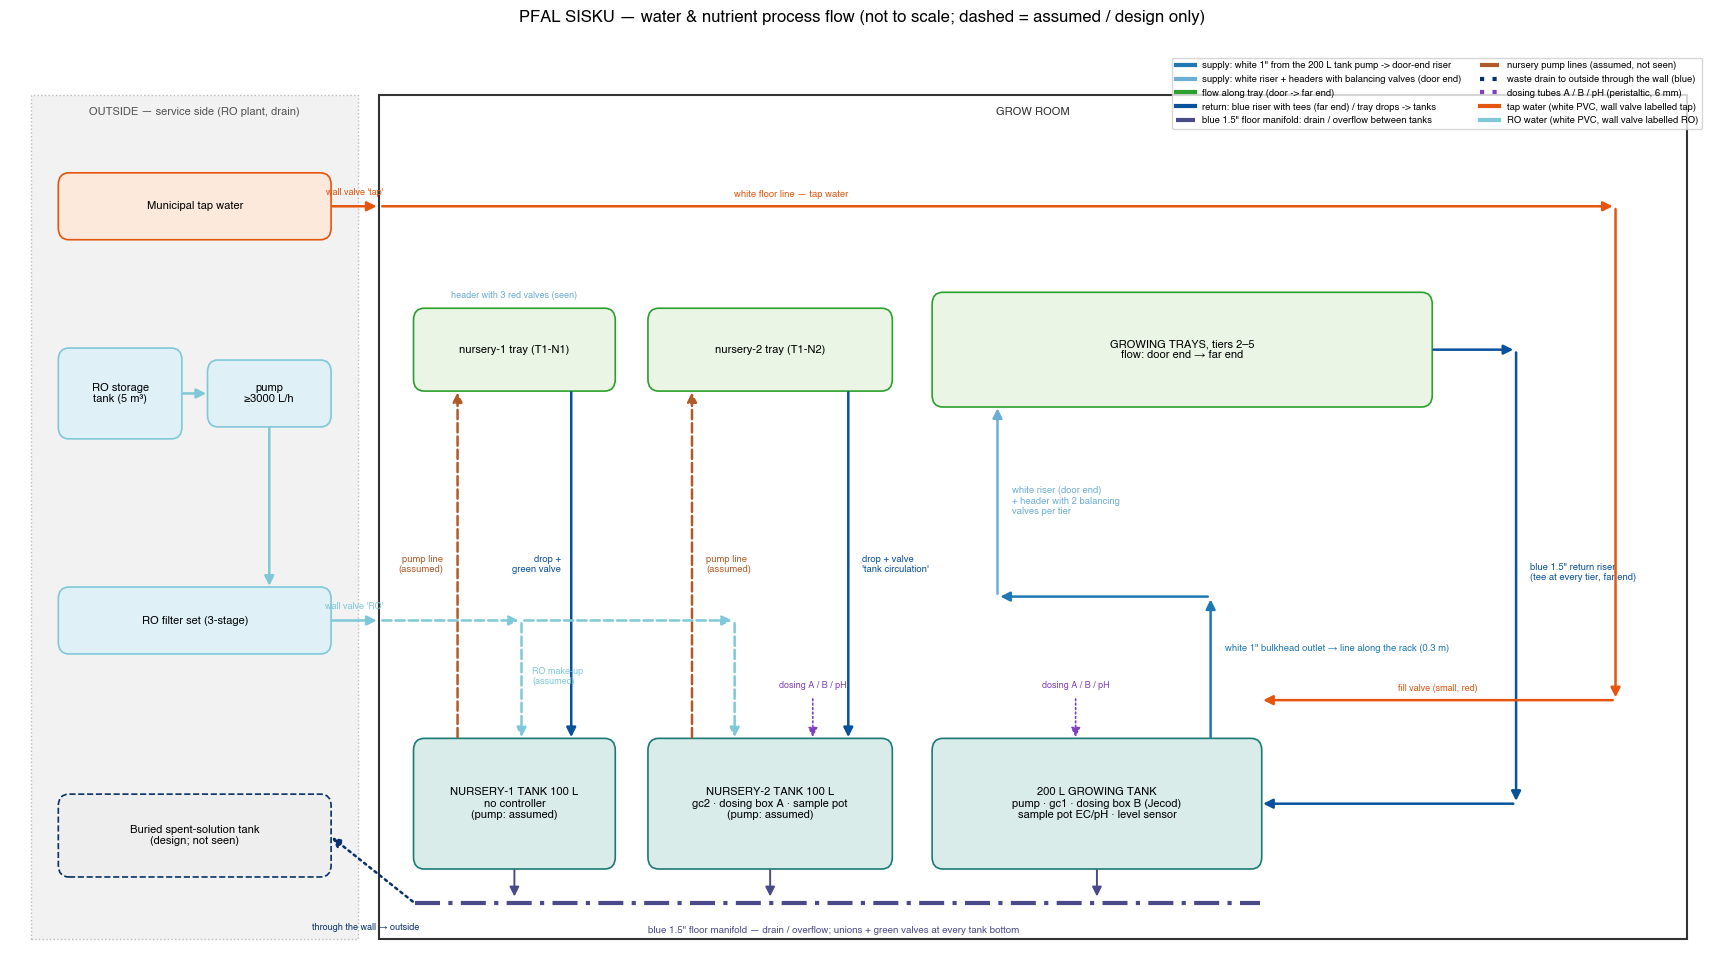

In [7]:
twin.water_plan(); twin.flow_diagram();

In [8]:
viz.show3d(twin.flow_animation(), None, height=700)

## L3 what-if

In [9]:
print(twin.light()); pd.Series(twin.heat_balance()).round(0).to_frame("W")

{'ppfd': 116.31959201019976, 'dli': 3.9239856678163125, 'led_kw': 1.344}


,W
"long wall (AC side, Y=W) -> outside",95.0
long wall (Y=0) minus windows -> outside/cafe,26.0
windows -> cafe,40.0
far wall (X=L) -> outside,40.0
partition (X=0) -> anteroom,19.0
roof -> outside,93.0
floor -> ground,18.0
infiltration,48.0
LED (growing tiers),1344.0
LED (nursery tier),336.0


In [10]:
assign, summary, fig = twin.crop_mix({"green oak": 50, "kale": 30, "basil": 20})     # 3-D by default
summary

,holes,share_pct,days_to_harvest,plant_fw_g,kg_per_cycle,cycles_per_year,kg_per_year,THB_per_year,DLI_need,DLI_available,light_ok
crop,,,,,,,,,,,
basil,140.0,20.0,40.0,80.0,11.2,9.1,102.0,20440.0,16.0,6.7,short by 9.3
green oak,350.0,50.0,35.0,150.0,52.5,10.4,548.0,65700.0,13.0,6.7,short by 6.3
kale,210.0,30.0,50.0,200.0,42.0,7.3,307.0,55188.0,16.0,6.7,short by 9.3
TOTAL,700.0,100.0,NaN,NaN,NaN,NaN,957.0,141328.0,NaN,NaN,NaN


## ข้อมูลย้อนหลัง — `twin.history(start, end, columns, freq)`
ดึงจากคลัง 10 นาทีในเครื่อง (ชื่อคอลัมน์ = `อุปกรณ์.key` เช่น `gw.xy_md_21_t`, `gc1.ec`, `co2.CO2`)

col,co2.CO2,gc1.ec
count,82.00,40.00
mean,578.60,1.16
std,159.07,0.42
min,429.00,0.73
25%,483.00,0.84
50%,522.25,0.86
75%,603.38,1.72
max,1212.00,2.05


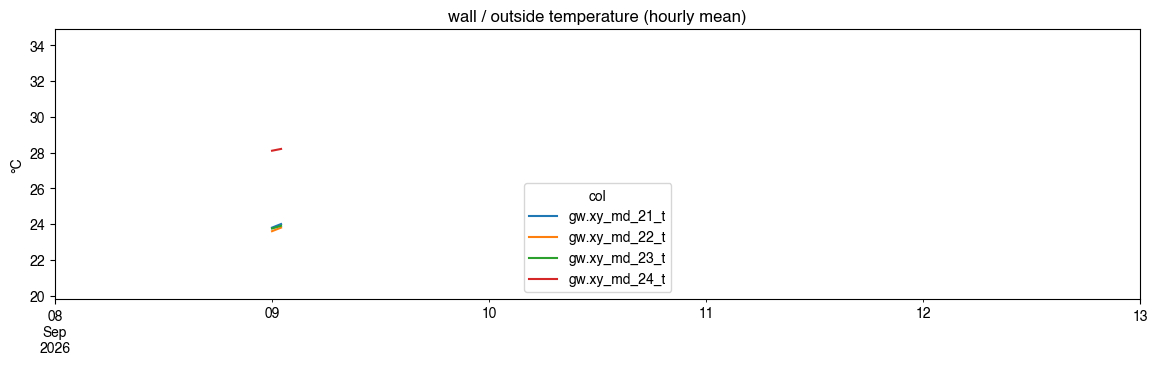

In [11]:
h = twin.history("2026-09-08", "2026-09-13", ["gw.xy_md_21_t", "gw.xy_md_22_t", "gw.xy_md_23_t", "gw.xy_md_24_t", "co2.CO2", "gc1.ec"], freq="1h")
ax = h.filter(like="_t").plot(figsize=(14, 3.5), title="wall / outside temperature (hourly mean)"); ax.set_ylabel("°C")
h[["co2.CO2", "gc1.ec"]].describe().round(2)

## ค่า live จาก ThingsBoard (ต้องมีอินเทอร์เน็ต) — `twin.live()` / `twin.figure_3d_live()`
ค่าล่าสุดของทุก key ตรงจาก server (ไม่ผ่านคลังในเครื่อง) พร้อมอายุของแต่ละค่า; ค่าที่เก่ากว่า 24 ชม. จะไม่ถูกใส่ใน twin

In [12]:
try:
    st_live, latest = twin.live()
    print(st_live.time, "| room T", st_live.room_T, "| CO2", st_live.co2, "| EC", st_live.ec, "| pumps", st_live.pump_on)
    display(latest.groupby("device")["age"].min().rename("age of newest value"))
    viz.show3d(twin.figure_3d(st=st_live, title_prefix="LIVE "), None, height=650)
except Exception as e:
    print("ThingsBoard not reachable:", e)

2026-09-14 18:35:47.688000+07:00 | room T 22.03333333333333 | CO2 1034.0 | EC {'growing (gc1)': 1.7898683547973633, 'nursery-2 (gc2)': 0.9960001707077026} | pumps {'gc1': True, 'gc2': False}


device
co2   0 days 00:02:48.129199
gc1   0 days 00:02:27.890199
gc2   0 days 00:02:26.210199
gw    0 days 09:13:26.347199
Name: age of newest value, dtype: timedelta64[ns]

## อัปเดตคลังในเครื่องจาก ThingsBoard (ต้องมีอินเทอร์เน็ต)

In [13]:
# twin.update_data()      # ดึงเฉพาะส่วนที่ใหม่กว่าไฟล์เดิม แล้วโหลดใหม่

## Web dashboard
ทุกอย่างข้างบนอยู่ในหน้าเว็บ `app/streamlit_app.py` (Live / History / Layout & water / What-if) — เปิดด้วย `scripts/run_app.sh` → http://localhost:8501